In [1]:
import pandas as pd

# Βάλαμε το \data\raw\ που υπήρχε στα αρχικά σου scripts
file_path = r"C:\Users\athin\Desktop\Car-Market-Analysis-Attica\data\raw\Car_DB_Attiki_Y2021_2026_Ext_29_01_2026.xlsx"

# Φόρτωση δεδομένων
df = pd.read_excel(file_path, skiprows=[1])

# Τύπωσε τις πρώτες γραμμές για επιβεβαίωση
df.head()

,Α/Α,Κατασκευαστής,Τύπος,Εγγραφή,Κυβικά,Ιπποδύναμη,Καύσιμο,Μετάδοση,Χιλιόμετρα,Τιμή,Κατάσταση,Περιγραφή,Περιοχή,Διεύθυνση,Σειρά Scraping,Ιστοσελίδα,Φωτογραφία 1,Φωτογραφία 2,Φωτογραφία 3
0,1,Audi,Q3,2025,1500,150,Βενζίνη,Αυτόματο,10500.0,34900,Μεταχειρισμένο,Q3 Advanced Plus 35 TFSI 150 hp S tronic,ΚΗΦΙΣΙΑ 14561,ΚΗΦΙΣΙΑ Ν. ΑΤΤΙΚΗΣ 14561,1769681066-1,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51909142_i_n.jpg,,
1,2,Toyota,Yaris Cross,2025,1500,116,Υβριδικό Βενζίνη,Αυτόματο,10018.0,25990,Μεταχειρισμένο,1.5-116ps-style!!,ΝΕΑ ΙΩΝΙΑ 14235,ΝΕΑ ΙΩΝΙΑ Ν. ΑΤΤΙΚΗΣ 14235,1769681066-2,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51329883_0_n.jpg,,
2,3,Peugeot,2008,2025,1200,145,Υβριδικό Βενζίνη,Αυτόματο,3000.0,26500,Μεταχειρισμένο,"Hybrid Allure - ΕΡΓΟΣΤΑΣΙΑΚΗ ΕΓΓΥΗΣΗ 5 ΕΤΗ, 30...",ΚΗΦΙΣΙΑ 14562,ΚΗΦΙΣΙΑ Ν. ΑΤΤΙΚΗΣ 14562,1769681066-3,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51432222_0_n.jpg,,
3,4,Peugeot,2008,2025,1200,145,Υβριδικό Βενζίνη,Αυτόματο,2900.0,26500,Μεταχειρισμένο,2008 Allure Hybrid Εργ. Εγγύηση 5 έτη - Μόνο 3...,ΝΕΑ ΕΡΥΘΡΑΙA 14671,ΝΕΑ ΕΡΥΘΡΑΙA Ν. ΑΤΤΙΚΗΣ 14671 ΝΕΑ ΕΡΥΘΡΑΙΑ,1769681066-4,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/51689355_0_n.jpg,,
4,5,Beev,ΒEEV-6,2025,Electric,4,Ηλεκτρικό,Αυτόματο,0.0,10900,Καινούργιο,ΒEEV-6 4P,ΓΛΥΚΑ ΝΕΡΑ 15354,ΓΛΥΚΑ ΝΕΡΑ Ν. ΑΤΤΙΚΗΣ 15354,1769681066-5,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/48676062_b_n.jpg,,


In [2]:
# --- ΚΕΛΙ ΚΑΘΑΡΙΣΜΟΥ ---
def clean_numeric_string(value):
    """Αφαιρεί τελείες και κενά και μετατρέπει το string σε αριθμό."""
    if pd.isna(value) or str(value).strip() == '':
        return None
    clean_val = ''.join(c for c in str(value) if c.isdigit())
    return int(clean_val) if clean_val else None

# Στήλες που θέλουμε να γίνουν καθαροί αριθμοί
numeric_cols = ['Κυβικά', 'Ιπποδύναμη', 'Χιλιόμετρα', 'Τιμή']

for col in numeric_cols:
    df[col] = df[col].apply(clean_numeric_string)

# Διαγράφουμε τις γραμμές που δεν έχουν τιμή, αφού δεν μπορούμε να τις αναλύσουμε
df = df.dropna(subset=['Τιμή'])

print(f"Αριθμός αυτοκινήτων μετά τον καθαρισμό: {len(df)}")

Αριθμός αυτοκινήτων μετά τον καθαρισμό: 8933


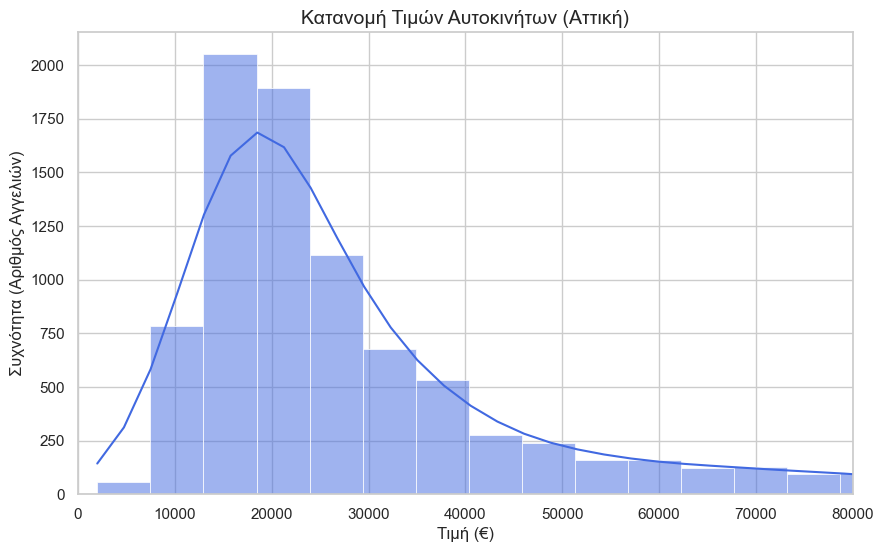

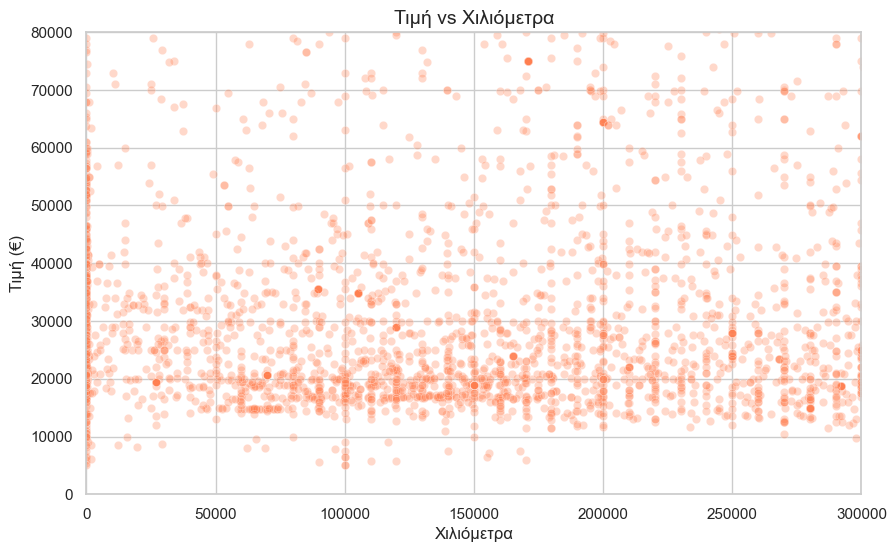

C:\Users\athin\AppData\Local\Temp\ipykernel_20632\3191342121.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['Καύσιμο'].isin(top_fuels)], y='Καύσιμο', order=top_fuels, palette='viridis')


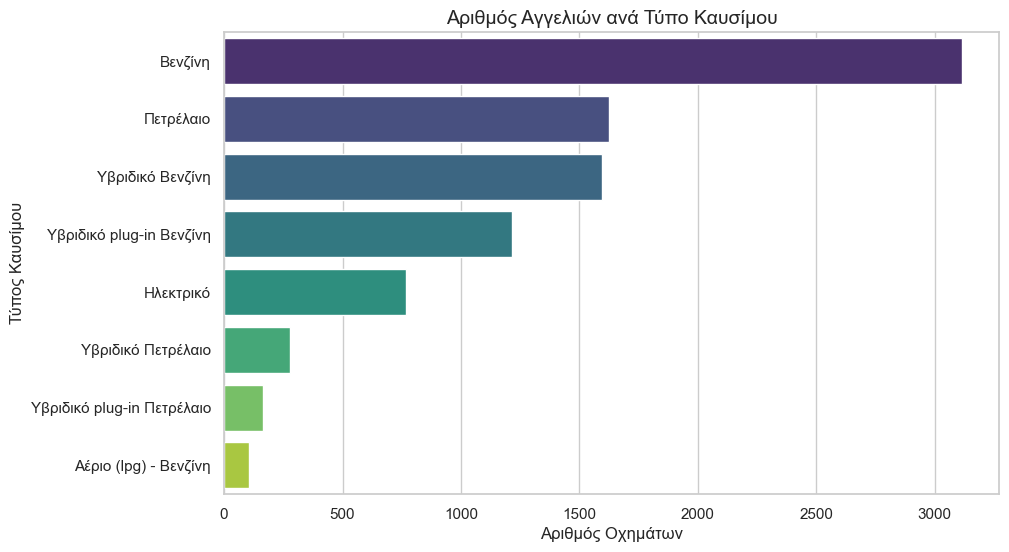

In [3]:
# --- ΚΕΛΙ ΓΡΑΦΗΜΑΤΩΝ ---
import matplotlib.pyplot as plt
import seaborn as sns

# Ρυθμίσεις για όμορφα γραφήματα
sns.set_theme(style="whitegrid")

# 1. Κατανομή Τιμών (Πού κυμαίνονται οι τιμές των αυτοκινήτων;)
plt.figure(figsize=(10, 6))
sns.histplot(df['Τιμή'], bins=100, kde=True, color='royalblue')
plt.title('Κατανομή Τιμών Αυτοκινήτων (Αττική)', fontsize=14)
plt.xlabel('Τιμή (€)', fontsize=12)
plt.ylabel('Συχνότητα (Αριθμός Αγγελιών)', fontsize=12)
plt.xlim(0, 80000) # Κόβουμε τα υπερβολικά ακριβά (π.χ. >80k) για να φαίνεται καθαρά ο κύριος όγκος
plt.show()

# 2. Συσχέτιση Χιλιομέτρων και Τιμής (Πέφτει η τιμή όσο αυξάνονται τα χιλιόμετρα;)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Χιλιόμετρα', y='Τιμή', alpha=0.3, color='coral')
plt.title('Τιμή vs Χιλιόμετρα', fontsize=14)
plt.xlabel('Χιλιόμετρα', fontsize=12)
plt.ylabel('Τιμή (€)', fontsize=12)
plt.xlim(0, 300000) # Εστιάζουμε στα 0 - 300.000 χλμ
plt.ylim(0, 80000)
plt.show()

# 3. Τα πιο δημοφιλή καύσιμα
plt.figure(figsize=(10, 6))
# Παίρνουμε τα top 8 καύσιμα για να μην μπουκώσει το γράφημα
top_fuels = df['Καύσιμο'].value_counts().nlargest(8).index 
sns.countplot(data=df[df['Καύσιμο'].isin(top_fuels)], y='Καύσιμο', order=top_fuels, palette='viridis')
plt.title('Αριθμός Αγγελιών ανά Τύπο Καυσίμου', fontsize=14)
plt.xlabel('Αριθμός Οχημάτων', fontsize=12)
plt.ylabel('Τύπος Καυσίμου', fontsize=12)
plt.show()

In [4]:
# 1. Βρίσκουμε το πλήθος των αγγελιών που ΔΕΝ έχουν χιλιόμετρα (είναι NaN/Null)
missing_km = df['Χιλιόμετρα'].isna().sum()
print(f"Αριθμός αγγελιών χωρίς χιλιόμετρα: {missing_km}")

# 2. Προαιρετικά: Εμφανίζουμε τις πρώτες 5 γραμμές αυτών των αγγελιών για να καταλάβουμε ΓΙΑΤΙ λείπουν
if missing_km > 0:
    print("\nΠαρακάτω φαίνονται οι αγγελίες χωρίς χιλιόμετρα:")
    display(df[df['Χιλιόμετρα'].isna()].head())

Αριθμός αγγελιών χωρίς χιλιόμετρα: 2

Παρακάτω φαίνονται οι αγγελίες χωρίς χιλιόμετρα:


,Α/Α,Κατασκευαστής,Τύπος,Εγγραφή,Κυβικά,Ιπποδύναμη,Καύσιμο,Μετάδοση,Χιλιόμετρα,Τιμή,Κατάσταση,Περιγραφή,Περιοχή,Διεύθυνση,Σειρά Scraping,Ιστοσελίδα,Φωτογραφία 1,Φωτογραφία 2,Φωτογραφία 3
1508,1509,ClubCar,Precedent Golf cart,2023,NaN,22,Ηλεκτρικό,Αυτόματο,NaN,9490,Μεταχειρισμένο,Precedent Flat-Bed Golf cart,ΚΟΡΩΠΙ 19400,ΚΟΡΩΠΙ Ν. ΑΤΤΙΚΗΣ 19400,1769681066-1621,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/11888811_v_n.jpg,https://static.car.gr/11888811_v_n.jpg,
3779,3780,ClubCar,Precedent,2022,NaN,22,Ηλεκτρικό,Αυτόματο,NaN,6490,Μεταχειρισμένο,Precedent 2 + 2 Seats,ΚΟΡΩΠΙ 19400,ΚΟΡΩΠΙ Ν. ΑΤΤΙΚΗΣ 19400,1769681066-4009,https://www.car.gr/classifieds/cars/?category=...,https://static.car.gr/11888764_n_n.jpg,https://static.car.gr/11888764_n_n.jpg,


In [5]:
# Διαγραφή των εγγραφών που δεν έχουν χιλιόμετρα
df = df.dropna(subset=['Χιλιόμετρα'])

print(f"Αριθμός αυτοκινήτων μετά την αφαίρεση των ελλιπών χιλιομέτρων: {len(df)}")

Αριθμός αυτοκινήτων μετά την αφαίρεση των ελλιπών χιλιομέτρων: 8931


In [6]:
# --- 1. ΕΛΕΓΧΟΣ ΓΙΑ ΔΙΠΛΟΤΥΠΑ ---
# Ελέγχουμε αν υπάρχουν αγγελίες με ίδια Μάρκα, Μοντέλο, Χρονιά, Χλμ και Τιμή
duplicates = df.duplicated(subset=['Κατασκευαστής', 'Τύπος ', 'Εγγραφή', 'Χιλιόμετρα', 'Τιμή']).sum()
print(f"1. Βρέθηκαν {duplicates} πιθανές διπλότυπες αγγελίες.")

# --- 2. ΕΛΕΓΧΟΣ ΓΙΑ ΚΕΝΑ (NaN) ΣΕ ΟΛΕΣ ΤΙΣ ΣΤΗΛΕΣ ---
print("\n2. Κενά (Ελλιπείς τιμές) ανά στήλη:")
print(df[['Κυβικά', 'Ιπποδύναμη', 'Καύσιμο', 'Μετάδοση', 'Εγγραφή']].isna().sum())

# --- 3. ΕΛΕΓΧΟΣ ΓΙΑ ΑΚΡΑΙΕΣ ΤΙΜΕΣ (Outliers) ---
print("\n3. Στατιστική σύνοψη για εντοπισμό παράλογων τιμών (Κοίτα τις γραμμές 'min' και 'max'):")
# Εμφανίζουμε τα στατιστικά για συγκεκριμένες στήλες και μετατρέπουμε το format για να διαβάζεται εύκολα
display(df[['Εγγραφή', 'Κυβικά', 'Ιπποδύναμη']].describe().round(0))

# Προαιρετικά: Εντοπισμός αυτοκινήτων με 0 κυβικά ή 0 άλογα
zero_cc = (df['Κυβικά'] == 0).sum()
zero_hp = (df['Ιπποδύναμη'] == 0).sum()
print(f"\nΑυτοκίνητα με 0 Κυβικά: {zero_cc}")
print(f"Αυτοκίνητα με 0 Ιπποδύναμη: {zero_hp}")

1. Βρέθηκαν 661 πιθανές διπλότυπες αγγελίες.

2. Κενά (Ελλιπείς τιμές) ανά στήλη:
Κυβικά        767
Ιπποδύναμη      0
Καύσιμο         0
Μετάδοση        0
Εγγραφή         0
dtype: int64

3. Στατιστική σύνοψη για εντοπισμό παράλογων τιμών (Κοίτα τις γραμμές 'min' και 'max'):


,Εγγραφή,Κυβικά,Ιπποδύναμη
count,8931.0,8164.0,8931.0
mean,2022.0,1574.0,180.0
std,1.0,593.0,119.0
min,2021.0,600.0,3.0
25%,2021.0,1200.0,109.0
50%,2022.0,1500.0,131.0
75%,2023.0,1700.0,218.0
max,2026.0,6400.0,1139.0



Αυτοκίνητα με 0 Κυβικά: 0
Αυτοκίνητα με 0 Ιπποδύναμη: 0


In [7]:
# --- 1. ΔΙΑΓΡΑΦΗ ΔΙΠΛΟΤΥΠΩΝ ---
print(f"Αριθμός αγγελιών ΠΡΙΝ τη διαγραφή διπλοτύπων: {len(df)}")
df = df.drop_duplicates(subset=['Κατασκευαστής', 'Τύπος ', 'Εγγραφή', 'Χιλιόμετρα', 'Τιμή'])
print(f"Αριθμός αγγελιών ΜΕΤΑ τη διαγραφή διπλοτύπων: {len(df)}")

# --- 2. ΤΙ ΣΥΜΒΑΙΝΕΙ ΜΕ ΤΑ ΚΕΝΑ ΚΥΒΙΚΑ; ---
print("\n--- Κατηγορίες καυσίμου για τα αυτοκίνητα χωρίς Κυβικά ---")
missing_cc_fuels = df[df['Κυβικά'].isna()]['Καύσιμο'].value_counts()
display(missing_cc_fuels)

# --- 3. ΠΟΙΑ ΕΙΝΑΙ ΤΑ ΑΥΤΟΚΙΝΗΤΑ ΜΕ < 30 ΑΛΟΓΑ; ---
print("\n--- Αγγελίες με ύποπτα χαμηλή ιπποδύναμη (< 30 hp) ---")
low_hp_cars = df[df['Ιπποδύναμη'] < 30][['Κατασκευαστής', 'Τύπος ', 'Ιπποδύναμη', 'Καύσιμο', 'Τιμή']]
display(low_hp_cars.head(10))

Αριθμός αγγελιών ΠΡΙΝ τη διαγραφή διπλοτύπων: 8931
Αριθμός αγγελιών ΜΕΤΑ τη διαγραφή διπλοτύπων: 8270

--- Κατηγορίες καυσίμου για τα αυτοκίνητα χωρίς Κυβικά ---


Καύσιμο
Ηλεκτρικό    711
Name: count, dtype: int64


--- Αγγελίες με ύποπτα χαμηλή ιπποδύναμη (< 30 hp) ---


,Κατασκευαστής,Τύπος,Ιπποδύναμη,Καύσιμο,Τιμή
4,Beev,ΒEEV-6,4,Ηλεκτρικό,10900
5,Beev,ΒEEV-5,5,Ηλεκτρικό,8250
17,Aixam,Scouty R,8,Ηλεκτρικό,8500
196,Κόμπακτ / Hatchback,Ecosmart x9,4,Ηλεκτρικό,6600
198,Κόμπακτ / Hatchback,Ecosmart X7,3,Ηλεκτρικό,5900
199,Κόμπακτ / Hatchback,Ecosmart SL,4,Ηλεκτρικό,9600
295,Zhidou,D2,27,Ηλεκτρικό,9900
298,Zhidou,D2,27,Ηλεκτρικό,10600
409,Xev,Yoyo,20,Ηλεκτρικό,12900
785,Xev,Yoyo,20,Ηλεκτρικό,13900


Κενά στα Κυβικά μετά τη διόρθωση: 0



C:\Users\athin\AppData\Local\Temp\ipykernel_20632\2812928381.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_makes.values, y=top_10_makes.index, palette='magma')


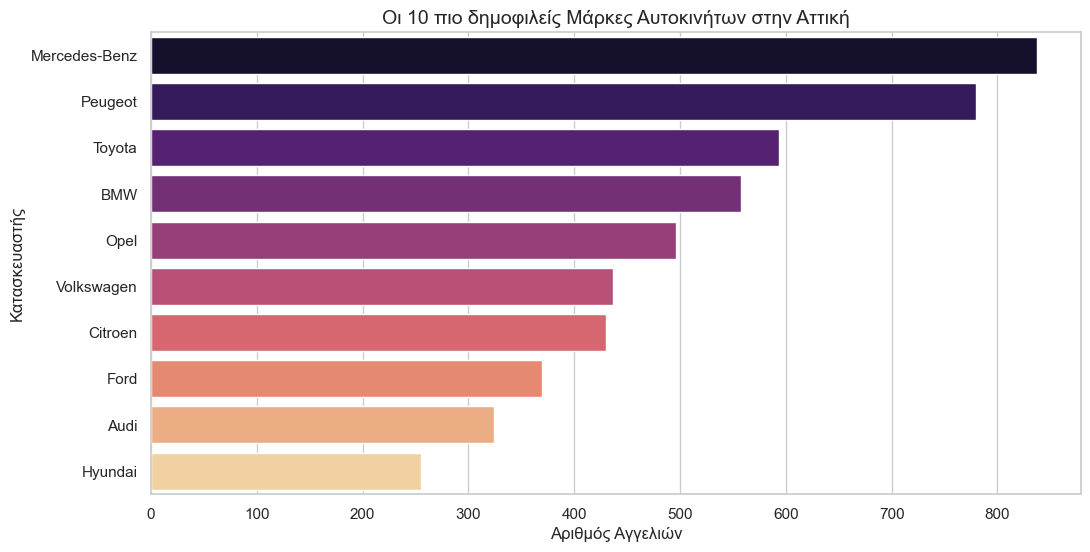

Μέση Τιμή για τις Top 10 Μάρκες (€):


Κατασκευαστής
Mercedes-Benz    57850.0
BMW              54745.0
Audi             47026.0
Ford             26337.0
Toyota           23726.0
Volkswagen       23453.0
Peugeot          19197.0
Hyundai          19135.0
Opel             16268.0
Citroen          15192.0
Name: Τιμή, dtype: float64


Το καθαρισμένο dataset αποθηκεύτηκε επιτυχώς ως 'Cleaned_Car_DB_Attiki.csv'!


In [8]:
# --- 1. ΔΙΟΡΘΩΣΗ ΚΥΒΙΚΩΝ ΣΤΑ ΗΛΕΚΤΡΙΚΑ ---
# Γεμίζουμε τα κενά (NaN) στη στήλη 'Κυβικά' με 0
df['Κυβικά'] = df['Κυβικά'].fillna(0)

# Επιβεβαίωση ότι δεν υπάρχουν πλέον κενά
print(f"Κενά στα Κυβικά μετά τη διόρθωση: {df['Κυβικά'].isna().sum()}\n")


# --- 2. FEATURE ENGINEERING (Δημιουργία Ηλικίας) ---
# Το τρέχον έτος ανάλυσης είναι το 2026
CURRENT_YEAR = 2026
df['Ηλικία'] = CURRENT_YEAR - df['Εγγραφή']

# Διορθώνουμε τυχόν αρνητικές ηλικίες (π.χ. αυτοκίνητα που δηλώθηκαν ως μοντέλα 2027) να γίνουν 0
df['Ηλικία'] = df['Ηλικία'].apply(lambda x: 0 if x < 0 else x)


# --- 3. ΓΡΑΦΗΜΑ: TOP 10 ΚΑΤΑΣΚΕΥΑΣΤΕΣ ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Βρίσκουμε τις 10 πιο συχνές μάρκες
top_10_makes = df['Κατασκευαστής'].value_counts().head(10)

sns.barplot(x=top_10_makes.values, y=top_10_makes.index, palette='magma')
plt.title('Οι 10 πιο δημοφιλείς Μάρκες Αυτοκινήτων στην Αττική', fontsize=14)
plt.xlabel('Αριθμός Αγγελιών', fontsize=12)
plt.ylabel('Κατασκευαστής', fontsize=12)
plt.show()


# --- 4. ΜΕΣΗ ΤΙΜΗ ΑΝΑ TOP ΜΑΡΚΑ ---
print("Μέση Τιμή για τις Top 10 Μάρκες (€):")
top_makes_list = top_10_makes.index.tolist()
mean_prices = df[df['Κατασκευαστής'].isin(top_makes_list)].groupby('Κατασκευαστής')['Τιμή'].mean().sort_values(ascending=False)
display(mean_prices.round(0))

# --- 5. ΑΠΟΘΗΚΕΥΣΗ ΤΟΥ ΚΑΘΑΡΟΥ DATASET ---
# Αποθηκεύουμε τα πεντακάθαρα δεδομένα μας για να τα χρησιμοποιήσουμε στο επόμενο Notebook!
df.to_csv('Cleaned_Car_DB_Attiki.csv', index=False)
print("\nΤο καθαρισμένο dataset αποθηκεύτηκε επιτυχώς ως 'Cleaned_Car_DB_Attiki.csv'!")

In [9]:
# --- 1. ΕΛΕΓΧΟΣ ΑΚΡΑΙΩΝ ΤΙΜΩΝ (OUTLIERS) ---
print("--- Έλεγχος Τιμών ---")
too_cheap = df[df['Τιμή'] < 1000]
too_expensive = df[df['Τιμή'] > 150000]
print(f"Αυτοκίνητα με τιμή < 1.000€: {len(too_cheap)}")
print(f"Αυτοκίνητα με τιμή > 150.000€: {len(too_expensive)}")

# Αν θες να δεις ποια είναι αυτά τα πολύ φθηνά (βγάλε το # από την παρακάτω γραμμή):
# display(too_cheap[['Κατασκευαστής', 'Τύπος ', 'Τιμή']])


# --- 2. ΚΑΘΑΡΙΣΜΟΣ ΚΑΤΗΓΟΡΙΩΝ ΚΑΙ ΚΕΝΩΝ ---
# Αφαιρούμε κρυφά κενά στην αρχή/τέλος από τις στήλες κειμένου
text_cols = ['Κατασκευαστής', 'Καύσιμο', 'Μετάδοση']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

print("\n--- Μοναδικές Κατηγορίες Σασμάν ---")
print(df['Μετάδοση'].value_counts())


# --- 3. ΑΦΑΙΡΕΣΗ ΣΤΗΛΩΝ ΠΟΥ ΔΕΝ ΠΡΟΣΦΕΡΟΥΝ ΣΤΗΝ ΠΡΟΒΛΕΨΗ ---
cols_to_drop = [
    'Α/Α', 'Σειρά Scraping', 'Ιστοσελίδα', 
    'Φωτογραφία 1', 'Φωτογραφία 2', 'Φωτογραφία 3'
]

# Ελέγχουμε αν υπάρχουν αυτές οι στήλες πριν τις διαγράψουμε (για αποφυγή σφάλματος)
cols_present = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_present)

print(f"\nΔιαγράφηκαν {len(cols_present)} μη χρηστικές στήλες.")
print(f"Τελικές στήλες για ανάλυση: {df.columns.tolist()}")

# Ξανα-αποθηκεύουμε το ΥΠΕΡ-ΚΑΘΑΡΟ dataset
df.to_csv('ML_Ready_Car_DB.csv', index=False)

--- Έλεγχος Τιμών ---
Αυτοκίνητα με τιμή < 1.000€: 0
Αυτοκίνητα με τιμή > 150.000€: 134

--- Μοναδικές Κατηγορίες Σασμάν ---
Μετάδοση
Αυτόματο       5245
Χειροκίνητο    3008
Ημιαυτόματο      17
Name: count, dtype: int64

Διαγράφηκαν 6 μη χρηστικές στήλες.
Τελικές στήλες για ανάλυση: ['Κατασκευαστής', 'Τύπος ', 'Εγγραφή', 'Κυβικά', 'Ιπποδύναμη', 'Καύσιμο', 'Μετάδοση', 'Χιλιόμετρα', 'Τιμή', 'Κατάσταση', 'Περιγραφή', 'Περιοχή', 'Διεύθυνση', 'Ηλικία']


In [10]:
# Κρατάμε μόνο τα αυτοκίνητα που κοστίζουν έως 150.000€
df = df[df['Τιμή'] <= 150000]